In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.simulation import Simulation
from src.config import Config
from src.builders import build_problem
from src.noise import add_noise_snr
from src.layers import create_layers_from_interfaces
from src.plot.plot_tools import set_plot_style
from sampling.parametrization import ModelParameterization
from sampling.posterior import FWIPosterior
from sampling.unconstrainedtarget import UnconstrainedTarget
#from sampling_toolbox.svgd import SVGD
from sampling_toolbox.utilities.kl_tracker import RelativeKLTracker
from sampling_toolbox.gauss_vi import GaussianODE

import time
set_plot_style()
save_figs=False
path_figs = ''

In [2]:
config = Config(n_receivers=8, x_min=600., x_max=2000.,
                   z_rec=50., z_src=20., x_src=50., nq_prop=256, f0=10., nq_evan=256, kx_max_factor=6,
                   total_time=2.0, delay=0.2, epsilon=1.25, free_surface=False, nfft_pad_factor=1, source_deriv=True)
param, acq = build_problem(config)
dxr = acq.xr[1] - acq.xr[0]
dt = param.dt
seed = 42
rng = np.random.default_rng(seed)

vps = np.array([1500.0, 2700.0, 3200.0])
vp_ref = np.array([vps[1], vps[2]])
z_int = np.array([0.0, 100., 250., 400.])
rhos = np.array([2000.0, 2000.0, 2000.0])
layers = create_layers_from_interfaces(z_int, vps, rhos)

sim = Simulation(config)
d_obs = sim.forward(layers)
d_obs_noise, std_noise = add_noise_snr(d_obs, snr_db=10, seed=seed)

In [3]:
mu = 2500.0 * np.ones(len(vp_ref))
sigma = 600.0 * np.ones(len(mu))
cov = np.diag(sigma**2)
beta = sim.param.dt / config.total_time
print(f"Tempering factor beta: {beta:.4f}")

param = ModelParameterization(
    layers,
    invert_vp=True,
    invert_h=False,
    startv=1,
    prior_mode='gaussian',
    mu=mu,
    cov=cov
)
param.vp_bounds = (800., 4500.)

bayes = FWIPosterior(
    dobs=d_obs_noise,
    parametrization=param,
    sim=sim,
    prior_mu=mu,
    prior_cov=cov,
    std_noise=float(std_noise),
    beta=beta,
)

Tempering factor beta: 0.0031


In [4]:
vp_min, vp_max, npts = 800, 4500, 120
vp_min2, vp_max2 = 800, 4500

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(vp_min2, vp_max2, npts)
xgrid, ygrid = np.meshgrid(x_vals, y_vals, indexing='xy')
logPOST = np.empty_like(xgrid)
start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid[i, j], ygrid[i, j]])
        logPOST[i,j]  = bayes.log_posterior(np.array([point[0], point[1]]))
elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")
print(f"time per forward is {elapsed_time/(npts*npts):.3f} seconds.")

generated misfit map in 750.205 seconds.
time per forward is 0.052 seconds.


In [5]:
# monitor KL divergence
max_logPOST = np.max(logPOST)
dx = x_vals[1] - x_vals[0]
dy = x_vals[1] - x_vals[0]
# Compute log(Z)
log_Z = max_logPOST + np.log(np.sum(np.exp(logPOST - max_logPOST))) + np.log(dx) + np.log(dy)
print(log_Z)

7.610781465276358


In [6]:
use_unconstrained=False
target = UnconstrainedTarget(bayes) if use_unconstrained else bayes

In [7]:
dt = 0.001
nit = 100
n_comp = 1
sigma = 200.
dtw = 0.1
integrator = 'heun_adaptive'

mu1 = [np.array([1900., 1900.])] 
Sigma1 = [np.diag([sigma**2, sigma**2])]
mu_in1 = [m.copy() for m in mu1]
R1 = [np.linalg.cholesky(Sigma1[i]) for i in range(n_comp)]

gvi_1 = GaussianODE(target.log_and_grad_post, step_size=dt, n_iter=nit, time_scheme=integrator, precond='natural', step_size_w=dtw, time_scheme_fr=integrator)
gvi_1.kl_track = RelativeKLTracker(log_Z)
final_mean_1, final_R_1, final_ws_1, means_1, Rs_1, ws_1, kl_hist_1 = gvi_1.sample([m.copy() for m in mu_in1], [r.copy() for r in R1])
gvi_1.report_calls()

Iter   1 | dt: 0.0012 | KL: 19.0470
weights [1.]
Iter   2 | dt: 0.0014 | KL: 17.8777
weights [1.]
Iter   3 | dt: 0.0017 | KL: 16.6757
weights [1.]
Iter   4 | dt: 0.0021 | KL: 15.4766
weights [1.]
Iter   5 | dt: 0.0025 | KL: 14.3122
weights [1.]
Iter   6 | dt: 0.0030 | KL: 13.2278
weights [1.]
Iter   7 | dt: 0.0036 | KL: 12.2346
weights [1.]
Iter   8 | dt: 0.0043 | KL: 11.3292
weights [1.]
Iter   9 | dt: 0.0052 | KL: 10.5170
weights [1.]
Iter  10 | dt: 0.0062 | KL: 9.8418
weights [1.]
Iter  11 | dt: 0.0074 | KL: 9.2489
weights [1.]
Iter  12 | dt: 0.0089 | KL: 8.6232
weights [1.]
Iter  13 | dt: 0.0107 | KL: 8.2894
weights [1.]
Iter  14 | dt: 0.0128 | KL: 7.8907
weights [1.]
Iter  15 | dt: 0.0154 | KL: 7.5441
weights [1.]
Iter  16 | dt: 0.0171 | KL: 7.2170
weights [1.]
Iter  17 | dt: 0.0205 | KL: 6.9411
weights [1.]
Iter  18 | dt: 0.0246 | KL: 6.6711
weights [1.]
Iter  19 | dt: 0.0295 | KL: 6.4037
weights [1.]
Iter  20 | dt: 0.0355 | KL: 6.1358
weights [1.]
Iter  21 | dt: 0.0425 | KL: 5.8

In [8]:
n_comp = 3
mu3 = [np.array([1900., 1900.]), np.array([2300., 3700.]), np.array([3500., 4000.])] 
Sigma3 = [np.diag([sigma**2, sigma**2]),  np.diag([sigma**2, sigma**2]), np.diag([sigma**2, sigma**2])]
mu_in3 = [m.copy() for m in mu3]
R3 = [np.linalg.cholesky(Sigma3[i]) for i in range(n_comp)]

gvi_3 = GaussianODE(target.log_and_grad_post, step_size=dt, n_iter=nit, time_scheme=integrator, precond='natural', step_size_w=dtw, time_scheme_fr=integrator)
gvi_3.kl_track = RelativeKLTracker(log_Z)
final_mean_3, final_R_3, final_ws_3, means_3, Rs_3, ws_3, kl_hist_3 = gvi_3.sample([m.copy() for m in mu_in3], [r.copy() for r in R3])
gvi_3.report_calls()

Iter   1 | dt: 0.0012 | KL: 12.0418
weights [0.32560075 0.33250803 0.34189121]
Iter   2 | dt: 0.0014 | KL: 11.5513
weights [0.31828034 0.3309592  0.35076046]
Iter   3 | dt: 0.0017 | KL: 11.0641
weights [0.31148546 0.32857109 0.35994345]
Iter   4 | dt: 0.0021 | KL: 10.5898
weights [0.30534942 0.32524283 0.36940775]
Iter   5 | dt: 0.0025 | KL: 10.1356
weights [0.30001459 0.32091133 0.37907407]
Iter   6 | dt: 0.0030 | KL: 9.7121
weights [0.29558953 0.31559583 0.38881465]
Iter   7 | dt: 0.0036 | KL: 9.3188
weights [0.29214424 0.30937976 0.398476  ]
Iter   8 | dt: 0.0043 | KL: 8.9514
weights [0.28970919 0.30239056 0.40790025]
Iter   9 | dt: 0.0052 | KL: 8.6084
weights [0.28826524 0.29478645 0.41694831]
Iter  10 | dt: 0.0062 | KL: 8.3001
weights [0.28765563 0.28677531 0.42556906]
Iter  11 | dt: 0.0074 | KL: 8.0092
weights [0.28780597 0.27848451 0.43370952]
Iter  12 | dt: 0.0089 | KL: 7.7008
weights [0.28896687 0.26993022 0.44110291]
Iter  13 | dt: 0.0107 | KL: 7.4642
weights [0.29035987 0.26

In [9]:
n_comp = 5
mu5 = [np.array([1900., 1900.]), np.array([3700., 2200.]), np.array([2300., 3700.]), np.array([2000., 3000.]), np.array([3500., 4000.])] 
Sigma5 = [np.diag([sigma**2, sigma**2]), np.diag([sigma**2, sigma**2]), np.diag([sigma**2, sigma**2]),  np.diag([sigma**2, sigma**2]), np.diag([sigma**2, sigma**2])]
mu_in5 = [m.copy() for m in mu5]
R5 = [np.linalg.cholesky(Sigma5[i]) for i in range(n_comp)]

#if use_unconstrained:
#    mu_in5, R5 = target.gmm_physical_to_unconstrained(mu5, sigma)

gvi_5 = GaussianODE(target.log_and_grad_post, step_size=dt, n_iter=nit, time_scheme=integrator, precond='natural', step_size_w=dtw, time_scheme_fr=integrator)
gvi_5.kl_track = RelativeKLTracker(log_Z)
final_mean_5, final_R_5, final_ws_5, means_5, Rs_5, ws_5, kl_hist_5 = gvi_5.sample([m.copy() for m in mu_in5], [r.copy() for r in R5])
gvi_5.report_calls()

Iter   1 | dt: 0.0012 | KL: 11.1764
weights [0.19654126 0.20559932 0.19944999 0.19500332 0.20340612]
Iter   2 | dt: 0.0014 | KL: 10.7435
weights [0.19343345 0.2113053  0.19865813 0.18986485 0.20673827]
Iter   3 | dt: 0.0017 | KL: 10.3088
weights [0.19070582 0.21710799 0.19761361 0.18459616 0.20997643]
Iter   4 | dt: 0.0021 | KL: 9.8783
weights [0.18837617 0.2229938  0.19631219 0.17921834 0.21309951]
Iter   5 | dt: 0.0025 | KL: 9.4576
weights [0.18644993 0.22894677 0.19475747 0.17375892 0.21608691]
Iter   6 | dt: 0.0030 | KL: 9.0539
weights [0.18490877 0.23495255 0.19296336 0.16825317 0.21892214]
Iter   7 | dt: 0.0036 | KL: 8.6673
weights [0.18372562 0.2410001  0.19094799 0.16273488 0.22159142]
Iter   8 | dt: 0.0043 | KL: 8.2958
weights [0.18287204 0.247081   0.18873224 0.15723228 0.22408244]
Iter   9 | dt: 0.0052 | KL: 7.9417
weights [0.18231639 0.25318911 0.18634228 0.15176724 0.22638498]
Iter  10 | dt: 0.0062 | KL: 7.6091
weights [0.18198866 0.25933411 0.18381214 0.14636593 0.2284991

In [10]:
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
from scipy.stats import norm

def plot_gmm(
    X,
    Y,
    logPOST,
    mus_hist,      # List or array containing the history of means over iterations
    Rs,
    mu0,           # Initial mean(s)
    weights=None,
    cmap="Blues",
    method="gvi"
):
    mus_hist = np.asarray(mus_hist)
    if mus_hist.ndim == 2:
        mus_hist = mus_hist[:, np.newaxis, :]
    num_components = mus_hist.shape[1]
    # Extract the final means from the last step of the history
    final_mus = mus_hist[-1] 
    # Standardize covariance factors (Rs)
    if num_components == 1 and np.ndim(Rs) == 2:
        Rs = [np.asarray(Rs)]
    else:
        Rs = [np.asarray(R) for R in Rs]
    # Standardize initial means (mu0)
    mu0 = np.asarray(mu0)
    if mu0.ndim == 1 and num_components == 1:
        mu0 = mu0[np.newaxis, :]
    # Handle component weights
    if weights is None:
        weights = np.ones(num_components) / num_components
    else:
        weights = np.asarray(weights, dtype=float)
        weights /= np.sum(weights)

    # True posterior (grid)
    POST = np.exp(logPOST - np.max(logPOST))
    Z = np.sum(POST)
    if Z == 0 or not np.isfinite(Z):
        raise ValueError("Posterior normalization failed (underflow). Reduce grid range or scale log density.")
    POST /= Z
    x_vals = X[0, :]
    y_vals = Y[:, 0]
    dx = x_vals[1] - x_vals[0]
    dy = y_vals[1] - y_vals[0]
    # Marginals (true from grid)
    py_true = np.sum(POST, axis=1) * dy
    px_true = np.sum(POST, axis=0) * dx
    px_true /= np.max(px_true)
    py_true /= np.max(py_true)

    # Compute GMM Analytical Marginals using Final Means
    px_gmm = np.zeros_like(x_vals)
    py_gmm = np.zeros_like(y_vals)

    for i in range(num_components):
        mu_final = final_mus[i]
        R = Rs[i]
        cov = R @ R.T
        w = weights[i]
        std_x = np.sqrt(cov[0, 0])
        std_y = np.sqrt(cov[1, 1])
        # Accumulate weighted 1D PDFs
        px_gmm += w * norm.pdf(x_vals, loc=mu_final[0], scale=std_x)
        py_gmm += w * norm.pdf(y_vals, loc=mu_final[1], scale=std_y)

    px_gmm /= np.max(px_gmm)
    py_gmm /= np.max(py_gmm)
    # Layout Setup
    fig = plt.figure(figsize=(6, 6))
    gs = GridSpec(
        2, 2,
        width_ratios=[4, 1],
        height_ratios=[1, 4],
        hspace=0.15,
        wspace=0.15,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_main = fig.add_subplot(gs[1, 0])
    ax_right = fig.add_subplot(gs[1, 1])

    # 2D Main Plot (Posterior, Trajectories, and Ellipses
    ax_main.contourf(X, Y, POST, levels=16, cmap=cmap)
    ax_main.contour(X, Y, POST, levels=16, colors="k", linewidths=0.5, alpha=0.5, linestyles='dashed')
    # 1. Plot Mean Trajectories for each Gaussian component
    if num_components == 1:
        colors_gmm = plt.cm.Reds(np.linspace(1., 0.4, max(num_components, 5)))
        colors_gmm[0] = mcolors.to_rgba("red")
    elif num_components == 3:
        colors_gmm = plt.cm.Greens(np.linspace(1., 0.4, max(num_components, 5)))
    else:
        colors_gmm = plt.cm.Greys(np.linspace(1., 0.4, max(num_components, 5)))
    for i in range(num_components):
        component_trajectory = mus_hist[:, i, :]
        ax_main.plot(
            component_trajectory[:, 0], 
            component_trajectory[:, 1], 
            color=colors_gmm[i], 
            linestyle="--", 
            alpha=0.5, 
            linewidth=1.5,
            zorder=3
        )
    # 2. Plot 1-sigma final ellipse with dashed red borders
    for i in range(num_components):
        mu_final = final_mus[i]
        R = Rs[i]
        cov = R @ R.T
        w = weights[i]

        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

        width, height = 2 * np.sqrt(vals)
        fill_alpha = max(w * 1., 0.01)  # Keeps it clean and clear under lines
        if num_components == 1:
            fill_alpha = 0.5

        gmm_rgb = colors_gmm[i][:3]
        matched_facecolor = (*gmm_rgb, fill_alpha)

        ellipse = Ellipse(
            xy=mu_final,
            width=width,
            height=height,
            angle=theta,
            edgecolor=colors_gmm[i],
            facecolor=matched_facecolor,
            linewidth=1.5,
            linestyle="-",
            label=method if i == 0 else "",
            zorder=4
        )
        ax_main.add_patch(ellipse)
        # Center of the components at termination step
        ax_main.scatter(mu_final[0], mu_final[1], color=colors_gmm[i], marker="x", s=35, alpha=1.0, zorder=5)
    
    # 3. Plot Initial Means with mu0 (Black Dots)
    for i in range(num_components):
        ax_main.scatter(mu0[i, 0], mu0[i, 1], color="black", marker="o", s=35, label="initial" if i == 0 else "", zorder=5)

    ax_main.set_xlabel(r"$v_1$ [m.s$^{-1}$]")
    ax_main.set_ylabel(r"$v_2$ [m.s$^{-1}$]")
    ax_main.set_xlim(1000., 4000.)
    ax_main.set_ylim(1000., 4000.)

    # Top Marginal Plot (x1)
    ax_top.plot(x_vals, px_true, lw=2, label="true")
    if num_components == 3:
        ax_top.plot(x_vals, px_gmm, lw=2, ls="--", label=f"K={num_components}", color='green')
    elif num_components == 5:
        ax_top.plot(x_vals, px_gmm, lw=2, ls="-.", label=f"K={num_components}", color='black')
    else:
        ax_top.plot(x_vals, px_gmm, lw=2, ls="-", label=f"K={num_components}", color='red')

    ax_top.set_xlim(1000., 4000.)
    ax_top.set_ylabel(r"$\pi_{\mathrm{post}}(v_1)$")
    ax_top.tick_params(axis="x", labelbottom=False)

    # Right Marginal Plot (x2)
    ax_right.plot(py_true, y_vals, lw=2, label="true")
    if num_components == 3:
        ax_right.plot(py_gmm, y_vals, lw=2, ls="--", label=method, color='green')
    elif num_components == 5:
        ax_right.plot(py_gmm, y_vals, lw=2, ls="-.", label=method, color='black')
    else:
        ax_right.plot(py_gmm, y_vals, lw=2, ls="-", label=method, color='red')

    ax_right.set_ylim(1000., 4000.)
    ax_right.set_xlabel(r"$\pi_{\mathrm{post}}(v_2)$")
    ax_right.tick_params(axis="y", labelleft=False)


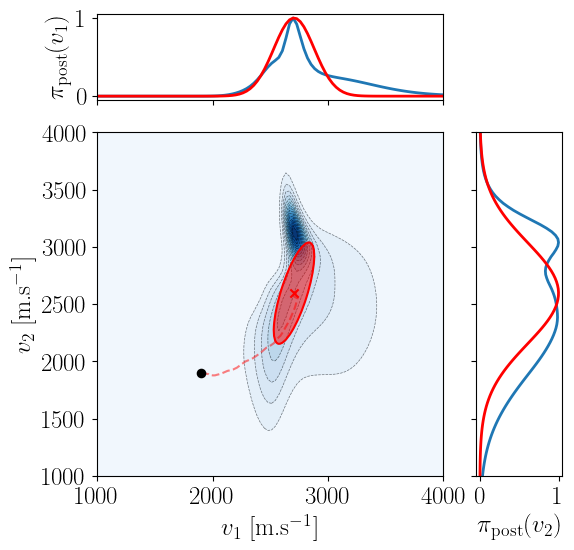

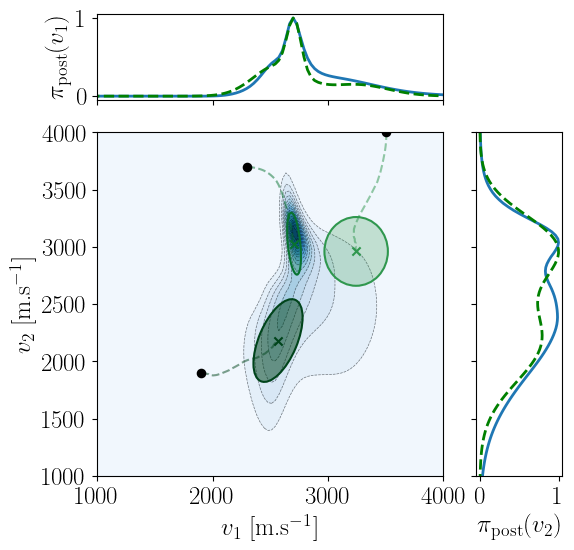

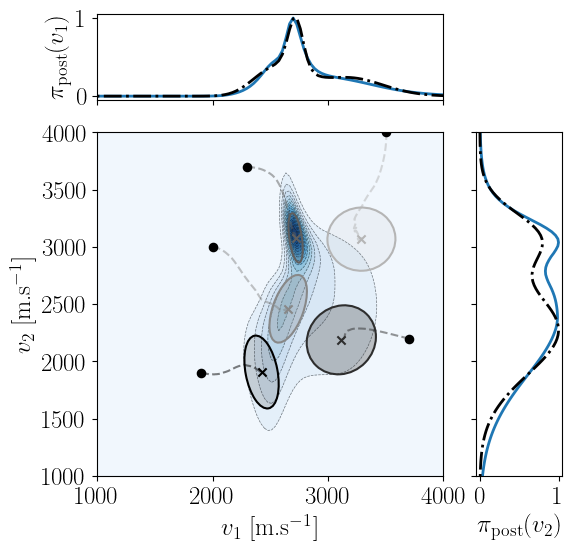

In [11]:
plot_gmm(xgrid, ygrid, logPOST, mus_hist=means_1, Rs=Rs_1[-1], weights=final_ws_1, method='natural', mu0=mu_in1)
if save_figs:
    plt.savefig(path_figs+'k1_post.pdf', dpi=300, bbox_inches='tight')
    plt.close()
else:
    plt.show()
    
plot_gmm(xgrid, ygrid, logPOST, mus_hist=means_3, Rs=Rs_3[-1], weights=final_ws_3, method='natural', mu0=mu_in3)
if save_figs:
    plt.savefig(path_figs+'k3_post.pdf', dpi=300, bbox_inches='tight')
    plt.close()
else:
    plt.show()

plot_gmm(xgrid, ygrid, logPOST, mus_hist=means_5, Rs=Rs_5[-1], weights=final_ws_5, method='natural', mu0=mu_in5)
if save_figs:
    plt.savefig(path_figs+'k5_post.pdf', dpi=300, bbox_inches='tight')
    plt.close()
else: 
    plt.show()

In [12]:
import numpy as np
from scipy.stats import multivariate_normal

def recompute_gmm_kl_grid(means_hist, Rs_hist, weights_hist, x_grid, y_grid, log_p_star_grid, logZ):
    """
    Recomputes the KL history over all iterations using pre-computed 2D grid.
    x_grid : 2D meshgrid X coordinates
    y_grid : 2D meshgrid Y coordinates
    log_p_star_grid : 2D evaluated unnormalized log-posterior
    logZ : normalization constant log(Z)
    """
    kl_history = []
    dx = x_grid[0, 1] - x_grid[0, 0]
    dy = y_grid[1, 0] - y_grid[0, 0]
    dA = dx * dy
    
    # Flatten the grid coordinates for fast vectorized PDF evaluation
    grid_points = np.column_stack([x_grid.ravel(), y_grid.ravel()])
    log_p_star_flat = log_p_star_grid.ravel()
    # p_target_flat = np.exp(log_p_star_flat - logZ)
    
    for t in range(len(means_hist)):
        mus = means_hist[t]
        Rs = Rs_hist[t]
        weights = weights_hist[t]
        n_comp = len(weights)
        # Evaluate the GMM density q(x) across the grid
        q_density_flat = np.zeros(len(grid_points))
        for i in range(n_comp):
            Sigma = Rs[i] @ Rs[i].T
            q_density_flat += weights[i] * multivariate_normal.pdf(grid_points, mean=mus[i], cov=Sigma)
        # Avoid log(0)
        log_q_flat = np.log(q_density_flat + 1e-15)
        
        # Discrete 2D Riemann sum
        log_p_flat = log_p_star_flat - logZ
        kl_integrand = q_density_flat * (log_q_flat - log_p_flat)
        kl_step = np.sum(kl_integrand) * dA
        kl_history.append(kl_step)
    return np.array(kl_history)

In [13]:
kl_history_grid_1 = recompute_gmm_kl_grid(
    means_hist=means_1, 
    Rs_hist=Rs_1, 
    weights_hist=ws_1, 
    x_grid=xgrid, 
    y_grid=ygrid, 
    log_p_star_grid=logPOST, 
    logZ=log_Z
)

kl_history_grid_3 = recompute_gmm_kl_grid(
    means_hist=means_3, 
    Rs_hist=Rs_3, 
    weights_hist=ws_3, 
    x_grid=xgrid, 
    y_grid=ygrid, 
    log_p_star_grid=logPOST, 
    logZ=log_Z
)

kl_history_grid_5 = recompute_gmm_kl_grid(
    means_hist=means_5, 
    Rs_hist=Rs_5, 
    weights_hist=ws_5, 
    x_grid=xgrid, 
    y_grid=ygrid, 
    log_p_star_grid=logPOST, 
    logZ=log_Z
)

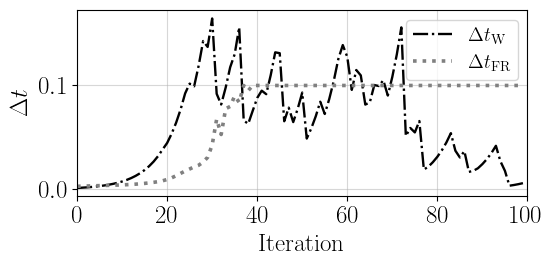

In [14]:
plt.figure(figsize=(6, 3.))
plt.plot(gvi_5.dt_history, color='k', lw=1.7, linestyle='-.', label=r'$\Delta t_{\mathrm{W}}$')
plt.plot(gvi_5.dt_fr_history, color='gray', lw=2.6, linestyle=':', label=r'$\Delta t_{\mathrm{FR}}$')
plt.xlabel(r'Iteration')
plt.xlim([0, nit])
plt.ylabel(r'$\Delta t$')
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
if save_figs:
    plt.savefig(path_figs+'dt_W_FR.pdf', dpi=300, bbox_inches='tight')
    plt.close()
else: 
    plt.show()

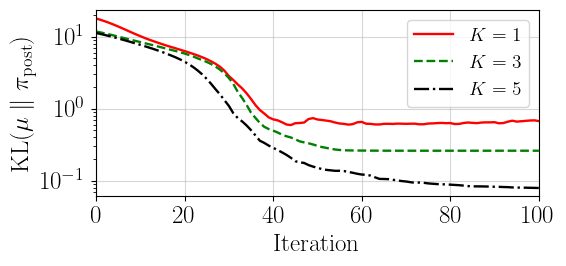

In [ ]:
plt.figure(figsize=(6, 2.25))
plt.plot(kl_history_grid_1, color='r', label=r'$K=1$', lw=1.7, linestyle='-')
plt.plot(kl_history_grid_3, color='g', label=r'$K=3$', lw=1.7, linestyle='--')
plt.plot(kl_history_grid_5, color='k', label=r'$K=5$', lw=1.7, linestyle='-.')
plt.xlabel(r'Iteration')
plt.ylabel(r'KL$(\mu \parallel \pi_{\mathrm{post}})$')
plt.yscale('log')
plt.xlim([0, nit])
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
if save_figs:
    plt.savefig(path_figs+'KL_hist.pdf', dpi=300, bbox_inches='tight')
    plt.close()
else: 
    plt.show()


In [21]:
path_figs = '/home/marchnep/Documents/Gitlab_repos/2026_MARCHNER_UQFWI/Fig/fwi_2vp/'
save_figs=True
plt.figure(figsize=(6, 2.5))
weights_arr = np.array(ws_5)
colors = plt.cm.Greys(np.linspace(1., 0.4, max(n_comp, 5)))
for k in range(n_comp):
    plt.plot(weights_arr[:, k], color=colors[k], lw=2, label=f"Comp {k}")
plt.xlabel(r'Iteration')
plt.ylabel(r'$w_k$')
plt.grid(True)
plt.xlim([0, nit])
if save_figs:
    plt.savefig(path_figs+'weights_k5.pdf', dpi=300, bbox_inches='tight')
    plt.close()
else:
    plt.show()